# Initializing polymer systems using a DPD potential
## Overview: (code adapted for GPU runs but can still run on CPU)
This notebook demonstrates how to run a molecular dynamics simulation of linear bead-spring polymers in the HOOMD-blue simulation engine, using the DPD potential on a random walk packed polymer box. This simulation achieves an intial frame to start a dense polymer melt simulation with another forcefield.

## Imports
The cell below includes imports directly from the code in this repository (ensure your system path matches where the source code exists), and packages from conda for visualization and analysis.

In [1]:
import sys
import os
sys.path.append('../lib/gpu/')
import create_system_dpd
from create_system_dpd import create_polymer_system_dpd, ejfire, fastfire
import matplotlib
import numpy as np  
import gsd, gsd.hoomd 
import hoomd 
import time
import freud
import matplotlib_inline
import matplotlib.pyplot as plt
%matplotlib inline
matplotlib.style.use("ggplot")
matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
import warnings
warnings.filterwarnings("ignore")

## Step by Step Guide to Core Functions

### Step 1: Call core function
This DPD MD simulation can be ran in a one line python call of `create_polymer_system_dpd()`. To this function, you pass your system parameters, length and number of polymer chains, density, along with DPD simulation parameters. This function primarily intializes the HOOMD simulation object and assigns the forcefield parameters. It contains a simulation loop that runs the MD simulation until an energy cutoff criteria is reached. We currently have this returning total simulation time, but the particle positions or the last hoomd frame can also be passed back.

### Step 1.1 Random Walk and Frame
The `create_polymer_system_dpd()` first calls the `initialize_snapshot_rand_walk` function. This function takes the linear topology and generates random positions for the chains in a random walk configuration, with periodic boundary conditions considered. It then initializes a hoomd frame with these coordinates and bead-spring parameters. 

### Step 1.2 Writers
HOOMD GSD writers and log writers can be initialized by passing the correct arguments to `create_polymer_system_dpd()`. Passing `write=True` will trigger file writing. File names and write frequencies can also be changed by passing the correct keyword parameters.

### Step 1.3 Simulation Cutoff
The simulation runs until `simulation_energy_end` is satisfied. This calculation is based on closest sphere packings and fraction of number density to the densest possible number density of 1.414.

In [2]:
nruns = 1
density=[1.2] #number density. 1.4 is close-packed, so things get weird above it!
npoly=2000
nmono=500
A=250000 #inter-particle repulsion A and bond-stiffness k seem to work well if they're about the same magnitude
k=250000
dt=0.001 #step sizes larger than 0.002 seem hard to keep numerically stable
gamma = 1500 #drag terms larger than 1200 seem to blow up
r_cut=1.05 #smaller r_cut means smaller neighbor lists, means faster, but larger helps push particles further apart
bond_l = 1.0 #bond length
N=npoly*nmono
print("N=",N,":")
for d in density:
    times = []
    rs = []
    for i in range(nruns):
        seed = np.random.randint(50000)
        closest, s, e_cut = fastfire(
            bond_l=bond_l,
            num_pol=npoly,
            num_mon=nmono,
            kT=1.0, #For this paper, keep kT const
            sim_seed=seed,
            np_seed=seed,
            sim_steps_incr=100,
            gsd_file_name='trajectory.gsd',
            gsd_write_freq=500,
            log_file_name='log.txt',
            log_write_freq=10,
            density=d,
            write = True,
            
            dt=dt,
            r_cut=r_cut,
            A=A,
            k=k,
            gamma=gamma,
        )
        times.append(s)
        rs.append(closest)
        #print("\t{:.2f}s, r = {:.2f} ".format(s,closest))
    print("density={:.2f}: {:.2f} ({:.2f})s , r = {:.2f} ({:.2f})".format(d,np.average(times),np.std(times), np.average(rs), np.std(rs)))


N= 1000000 :
density=1.20: 17.95 (0.00)s , r = 0.87 (0.00)


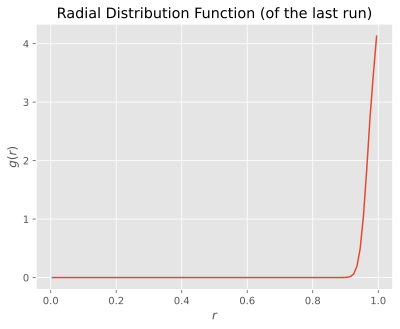

In [3]:
rdf_data = np.genfromtxt("rdf.csv", delimiter=",")
plt.plot(rdf_data[:, 0], rdf_data[:, 1])
plt.title("Radial Distribution Function (of the last run)")
plt.xlabel("$r$")
plt.ylabel("$g(r)$")
plt.show()
#print(rdf_data)

Total steps 7200


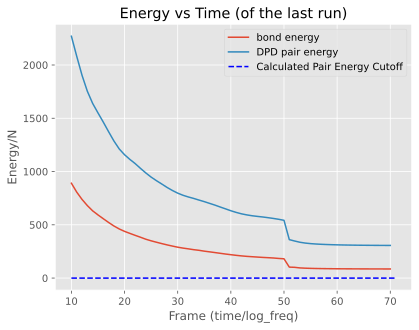

In [4]:
slice_idx = 10
short_idx= None

log = np.genfromtxt("log.txt", names=True)
pe = log["mdcomputeThermodynamicQuantitiespotential_energy"]
pairs = log["mdpairDPDenergy"]
print("Total steps",len(pe)*100+100)
x_values = range(slice_idx, len(pe[:short_idx]))
plt.plot(x_values,(pe[slice_idx:short_idx] - pairs[slice_idx:short_idx])/N, label="bond energy")
plt.plot(x_values,pairs[slice_idx:short_idx]/N, label="DPD pair energy")
plt.hlines(e_cut,xmin=slice_idx,xmax=len(pairs[:short_idx]),color="blue",linestyle="--",label="Calculated Pair Energy Cutoff")
plt.title("Energy vs Time (of the last run)")
plt.xlabel("Frame (time/log_freq)")
plt.ylabel("Energy/N")
plt.legend()